In [22]:
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [4]:
df = pd.read_csv('../data/raw/combined_data.csv')
df.head()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_26944\3062198473.py:1: DtypeWarning: Columns (0: required_age) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/combined_data.csv')


,appid,category_name,type,is_free,release_date,required_age,short_description,supported_languages,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,created_at,updated_at,category_name.1,developer_id,genre_id,platforms,publisher_id
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",161854.0,999.0,999.0,0.0,USD,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,"Color Alternatives, Pvp, Family Sharing, Multi...",59202.0,122.0,"['windows', 'mac', 'linux']",50182.0
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",6633.0,499.0,499.0,0.0,USD,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,"Pvp, Family Sharing, Multi-Player, Keyboard On...",59202.0,122.0,"['windows', 'mac', 'linux']",50182.0
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",4308.0,499.0,499.0,0.0,USD,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,"Color Alternatives, Family Sharing, Multi-Play...",59202.0,122.0,"['windows', 'mac', 'linux']",50182.0
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2338.0,499.0,499.0,0.0,USD,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,"Color Alternatives, Pvp, Family Sharing, Multi...",59202.0,122.0,"['windows', 'mac', 'linux']",50182.0
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",22793.0,499.0,499.0,0.0,USD,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00,"Adjustable Difficulty, Family Sharing, Multi-P...",21806.0,122.0,"['windows', 'mac', 'linux']",50182.0


In [5]:
print(df.dtypes)

appid                      int64
category_name                str
type                         str
is_free                     bool
release_date                 str
required_age              object
short_description            str
supported_languages          str
recommendations_total    float64
mat_initial_price        float64
mat_final_price          float64
mat_discount_percent     float64
mat_currency                 str
created_at                   str
updated_at                   str
category_name.1              str
developer_id             float64
genre_id                 float64
platforms                    str
publisher_id             float64
dtype: object


### first of all here we can see that theres some columns with wrong datatype 
### the release_date,required_age,created_at,updated_at (with wrong datatype)

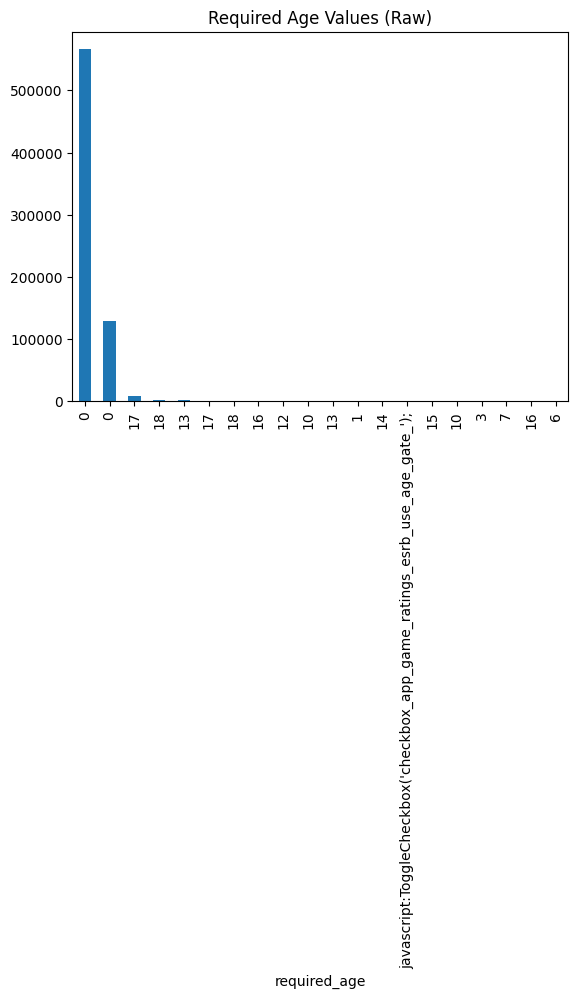

In [7]:
df['required_age'].value_counts().head(20).plot(kind='bar')
plt.title("Required Age Values (Raw)")
plt.show()

## here we can see that the required_age column had some kind of weird value

In [8]:
df['required_age'] = pd.to_numeric(df['required_age'], errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')

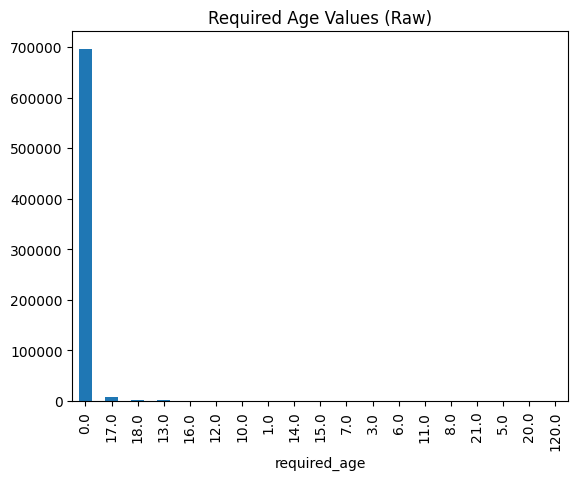

In [9]:
df['required_age'].value_counts().head(20).plot(kind='bar')
plt.title("Required Age Values (Raw)")
plt.show()

## by fix the wrong datatype we can see that bar char fixed give the wrong values

In [11]:
df.isnull().sum().sort_values(ascending=False)

recommendations_total    631980
mat_final_price          267793
mat_discount_percent     267793
mat_initial_price        267793
mat_currency             267793
release_date             120202
publisher_id              53170
genre_id                  34773
supported_languages       20256
category_name.1           18216
short_description         17433
developer_id              11451
type                       3183
required_age                 62
category_name                10
appid                         0
is_free                       0
created_at                    0
updated_at                    0
platforms                     0
dtype: int64

###
###
## here we saw that we got some columns with some null values but that show the null values the dataset may got some whitespace somwhere 
## so we may use a code to convert the whitespace to nan values so we can make sure theres any un seen nulls in the dataset

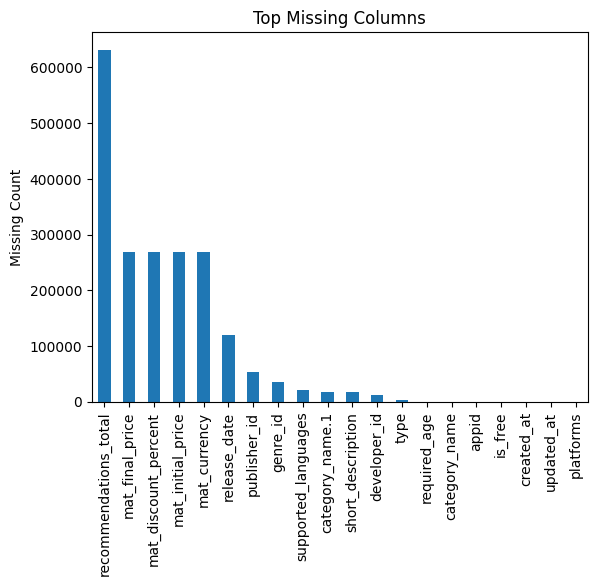

In [12]:
plt.figure()
df.isnull().sum().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title("Top Missing Columns")
plt.ylabel("Missing Count")
plt.show()

## that bar chart shows us the most columns with missing values

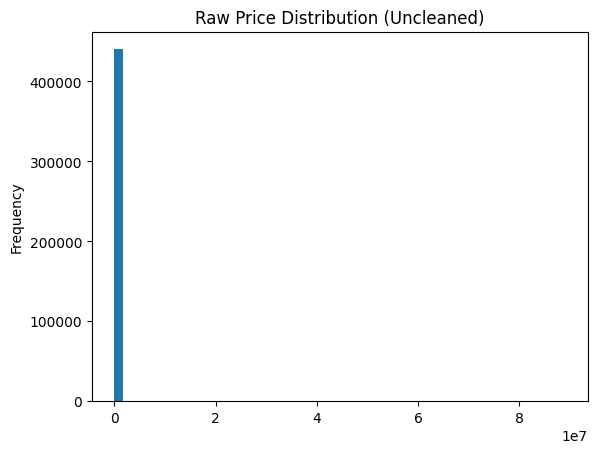

In [13]:
plt.figure()
df['mat_final_price'].plot(kind='hist', bins=50)
plt.title("Raw Price Distribution (Uncleaned)")
plt.show()

## The tall bar near zero shows that most values are clustered at very low prices, while a few extreme values stretch the axis far to the right. That’s a sign of heavy skew.

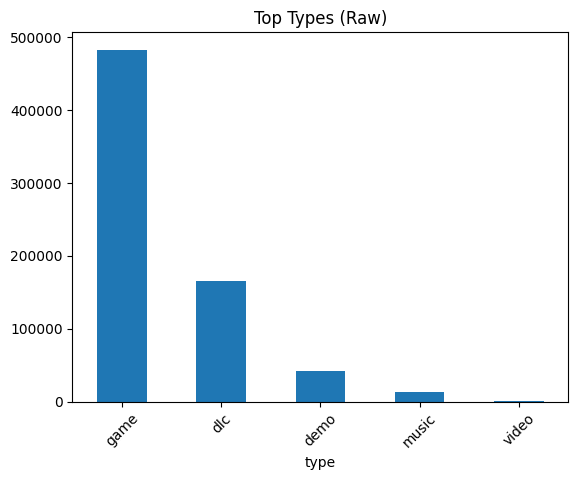

In [14]:
df['type'].value_counts().head(10).plot(kind='bar')
plt.title("Top Types (Raw)")
plt.xticks(rotation=45)
plt.show()

In [15]:
print(df['type'].unique())

<StringArray>
['game', 'demo', 'dlc', nan, 'music', 'video']
Length: 6, dtype: str


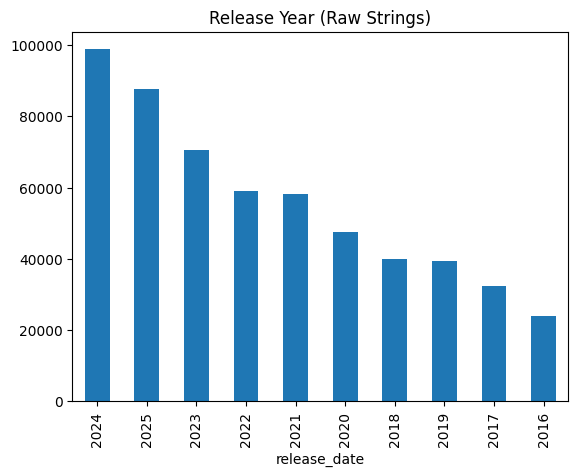

In [16]:
df['release_date'].astype(str).str[:4].value_counts().head(10).plot(kind='bar')
plt.title("Release Year (Raw Strings)")
plt.show()

# Outliers Detection


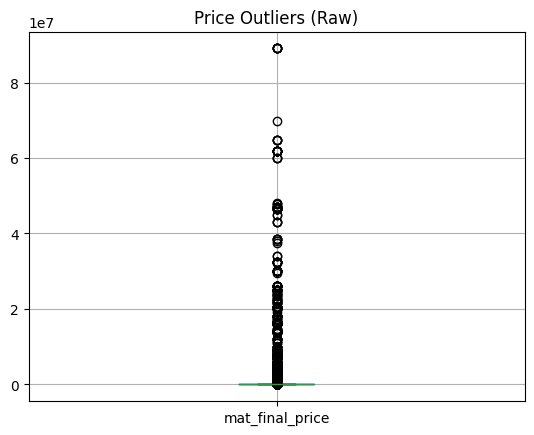

In [17]:
plt.figure()
df.boxplot(column='mat_final_price')
plt.title("Price Outliers (Raw)")
plt.show()

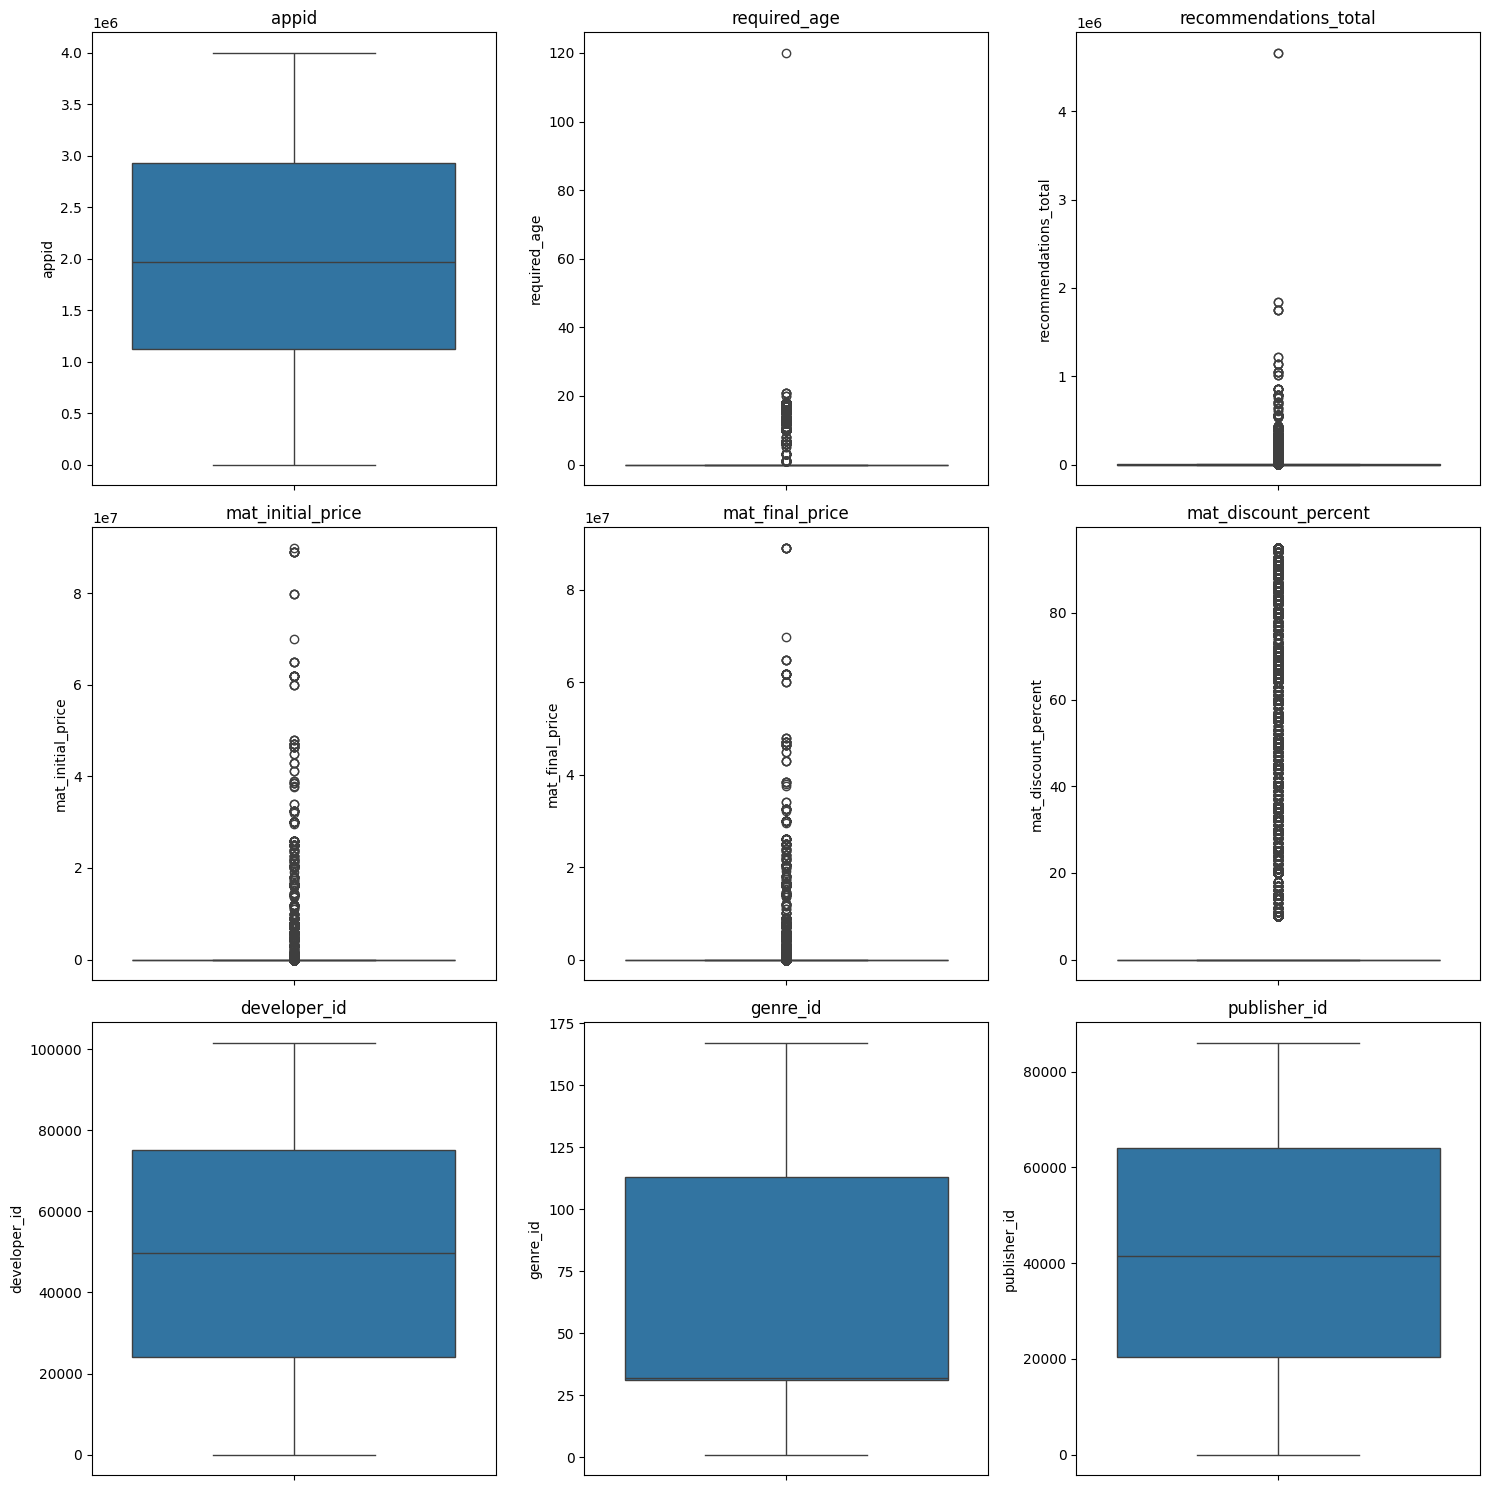

In [23]:
numeric_cols = df.select_dtypes(include=['number']).columns

# Decide grid size: 3 plots per row
ncols = 3
nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 5*nrows))

# Flatten axes for easy iteration
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')

# Hide any unused subplots (if number of columns not divisible by 3)
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## here we can see thta we got five columns with high outlires
## maybe becuse theres high missing values idk